## Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tkinter.messagebox import IGNORE
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

## VERIFICACION DATOS FALTANTES

In [3]:
# EXTRACION DE DATA PREPROCESADA
df_datos_preprocesados = pd.read_csv('../../data/processed/DATOS_PROCESADOS_temp_roc.csv')

In [38]:
df_pre_copy = df_datos_preprocesados.copy()

In [39]:
df_pre_copy.head()

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
0,2006-07-20 00:00:00.000,2006,7,20,0,03004KT,13.0,8.0
1,2006-07-20 01:00:00.000,2006,7,20,1,29004KT,11.0,10.0
2,2006-07-20 05:00:00.000,2006,7,20,5,VRB02KT,9.0,9.0
3,2006-07-20 06:00:00.000,2006,7,20,6,VRB02KT,8.0,8.0
4,2006-07-20 07:00:00.000,2006,7,20,7,VRB02KT,9.0,8.0


valores nulos en temperatura y rocio

In [40]:
#contar el numero de registros donde las columnas de temperatura y punto de rocío son nulas vs cantidad de registros totales
total_registros = len(df_pre_copy)
nulos_temperatura = df_pre_copy['temperatura'].isnull().sum()
nulos_rocio = df_pre_copy['rocio'].isnull().sum()
print(f"Total de registros: {total_registros}")
print(f"Registros con temperatura nula: {nulos_temperatura} ({(nulos_temperatura / total_registros) * 100:.2f}%)")
print(f"Registros con punto de rocío nulo: {nulos_rocio} ({(nulos_rocio / total_registros) * 100:.2f}%)")
#mostrar registros con temperatura nula pero con punto de rocío no nulo
diferencias =df_pre_copy[(df_pre_copy['temperatura'].isnull()) & (df_pre_copy['rocio'].notnull())]
print(f"Registros con temperatura nula pero punto de rocío no nulo: {len(diferencias)}")
df_pre_copy[df_pre_copy['temperatura'].isnull()].head()

Total de registros: 169764
Registros con temperatura nula: 267 (0.16%)
Registros con punto de rocío nulo: 267 (0.16%)
Registros con temperatura nula pero punto de rocío no nulo: 0


,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
282,2006-09-05 10:00:00.000,2006,9,5,10,31003KT,NaN,NaN
401,2006-09-11 09:00:00.000,2006,9,11,9,VRB02KT,NaN,NaN
1066,2006-10-13 07:00:00.000,2006,10,13,7,30002KT,NaN,NaN
1420,2006-12-28 13:00:00.000,2006,12,28,13,02005KT,NaN,NaN
1874,2007-03-23 00:00:00.000,2007,3,23,0,VRB02KT,NaN,NaN


In [41]:
# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df_pre_copy['FECHA_REPORTE'] = pd.to_datetime(df_pre_copy['FECHA_REPORTE'])
df_pre_copy.set_index('FECHA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df_pre_copy.drop(columns=['Año', 'Mes', 'Dia', 'Hora'], inplace=True)

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df_pre_copy = df_pre_copy[df_pre_copy['viento'].notna()]

# Modificar el valor KKT, T, K  por KT en la columna de viento
df_pre_copy['viento'] = df_pre_copy['viento'].str.replace(r'[A-Za-z]{3}$', 'KT', regex=True)

def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])

    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)

    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)

        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)

        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0

        return pd.Series([direccion, velocidad, rafaga])

    return pd.Series([None, None, None])

# Aplicación Regex para parsear la columna de viento con formato flexible
df_pre_copy[['direccion', 'intensidad_kt', 'rafaga_kt']] = df_pre_copy['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df_pre_copy['direccion'] = df_pre_copy['direccion'].ffill()

# Elimino errores de digitación, por lo cual me quedo cuando la longitud de viento es mayor a 7
df_pre_copy = df_pre_copy[df_pre_copy['viento'].str.len() > 6]

# Elimino aquellos que no se identifica intensidad del viento
df_pre_copy = df_pre_copy[df_pre_copy["intensidad_kt"].notnull()]

# Verificar cuantos no tienen la estructura
df_pre_copy["viento"].str.len().value_counts()

# Eliminar valores donde la dirección es muy desfazada
df_pre_copy = df_pre_copy[df_pre_copy["direccion"] <= 360]


In [8]:
df_pre_copy.tail()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt
FECHA_REPORTE,,,,,,
2026-04-09 14:27:00,16014G25KT,17.0,10.0,160.0,14.0,25.0
2026-04-09 15:00:00,15017KT,18.0,10.0,150.0,17.0,0.0
2026-04-09 16:00:00,18015KT,17.0,10.0,180.0,15.0,0.0
2026-04-09 17:00:00,15011KT,17.0,10.0,150.0,11.0,0.0
2026-04-09 18:00:00,17011KT,18.0,10.0,170.0,11.0,0.0


### Datos faltantes

In [42]:
# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('h'),
                              end=df_pre_copy.index.max().ceil('h'),
                              freq='1h')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df_pre_copy.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df_pre_copy[df_pre_copy.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 13337
Reportes extra encontrados: 9782


In [43]:
df_pre_copy

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt
FECHA_REPORTE,,,,,,
2006-07-20 00:00:00,03004KT,13.0,8.0,30.0,4.0,0.0
2006-07-20 01:00:00,29004KT,11.0,10.0,290.0,4.0,0.0
2006-07-20 05:00:00,VRB02KT,9.0,9.0,290.0,2.0,0.0
2006-07-20 06:00:00,VRB02KT,8.0,8.0,290.0,2.0,0.0
2006-07-20 07:00:00,VRB02KT,9.0,8.0,290.0,2.0,0.0
...,...,...,...,...,...,...
2026-04-09 14:27:00,16014G25KT,17.0,10.0,160.0,14.0,25.0
2026-04-09 15:00:00,15017KT,18.0,10.0,150.0,17.0,0.0
2026-04-09 16:00:00,18015KT,17.0,10.0,180.0,15.0,0.0


#### Descomposicion de dirección e intensidad del viento

In [44]:
# =========================================================
# FASE 1: PREPARACIÓN DEL ÍNDICE Y CÁLCULO DE COMPONENTES
# =========================================================

# Asegurarnos de que el índice de dataset original es formato datetime
df_pre_copy.index = pd.to_datetime(df_pre_copy.index)

# PASO CRÍTICO: Redondear los reportes a la hora en punto más cercana.
# Esto sincroniza reportes emitidos al minuto 50-59 con la hora exacta.
df_pre_copy.index = df_pre_copy.index.round('h')

# Al redondear, un reporte regular y un reporte especial (SPECI) podrían caer
# en la misma hora. Conservamos el último (el más actualizado).
df_pre_copy = df_pre_copy[~df_pre_copy.index.duplicated(keep='last')]

# Calcular u y v desde cero:
df_pre_copy['dir_sin'] = np.sin(np.radians(df_pre_copy['direccion'])) 
df_pre_copy['dir_cos'] = np.cos(np.radians(df_pre_copy['direccion']))

In [45]:
df_pre_copy.head()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt,dir_sin,dir_cos
FECHA_REPORTE,,,,,,,,
2006-07-20 00:00:00,03004KT,13.0,8.0,30.0,4.0,0.0,0.500000,0.866025
2006-07-20 01:00:00,29004KT,11.0,10.0,290.0,4.0,0.0,-0.939693,0.342020
2006-07-20 05:00:00,VRB02KT,9.0,9.0,290.0,2.0,0.0,-0.939693,0.342020
2006-07-20 06:00:00,VRB02KT,8.0,8.0,290.0,2.0,0.0,-0.939693,0.342020
2006-07-20 07:00:00,VRB02KT,9.0,8.0,290.0,2.0,0.0,-0.939693,0.342020


Los mejores datos a tomar para que luego de la imputacion ,no se presente mucho sesgo es desde el 2013 (inclusive).

In [47]:
# 2. Definir reglas de agregación para tus columnas
reglas = {
    'dir_sin': 'mean',          # Promedio de la componente zonal
    'dir_cos': 'mean',          # Promedio de la componente meridional
    'intensidad_kt': 'mean',
    'rafaga_kt': 'max',    # Capturamos la ráfaga más fuerte de la hora
    'temperatura': 'mean', # Promedio de temperatura
    'rocio': 'mean'       # Promedio de punto de rocío
}

# 3. Forzar la frecuencia horaria (Resample)
df_modelo = df_pre_copy.resample('1h').agg(reglas)

# 4. Mantener la continuidad para el modelo (Interpolación)
# El LSTM requiere que no existan huecos en la secuencia
df_modelo['dir_sin'] = df_modelo['dir_sin'].interpolate(method='linear')
df_modelo['dir_cos'] = df_modelo['dir_cos'].interpolate(method='linear')
df_modelo['intensidad_kt'] = df_modelo['intensidad_kt'].interpolate(method='linear')
df_modelo['rafaga_kt'] = df_modelo['rafaga_kt'].fillna(0) # Si no hay reporte, rafaga es 0
# Conservar las columnas 'temperatura' y 'rocio' en df_modelo
df_modelo['temperatura'] = df_modelo['temperatura'].interpolate(method='linear')
df_modelo['rocio'] = df_modelo['rocio'].interpolate(method='linear')

In [33]:
df_modelo.tail()

,dir_sin,dir_cos,rafaga_kt,temperatura,rocio
FECHA_REPORTE,,,,,
2026-04-09 14:00:00,3.420201e-01,-0.939693,25.0,17.0,10.0
2026-04-09 15:00:00,5.000000e-01,-0.866025,0.0,18.0,10.0
2026-04-09 16:00:00,1.224647e-16,-1.000000,0.0,17.0,10.0
2026-04-09 17:00:00,5.000000e-01,-0.866025,0.0,17.0,10.0
2026-04-09 18:00:00,1.736482e-01,-0.984808,0.0,18.0,10.0


In [34]:
# Muestra la sumatoria de valores NaN en cada columna
print("Cantidad de valores faltantes por columna:")
print(df_modelo.isnull().sum())

# Verifica si la frecuencia horaria es estrictamente regular
print("\n¿Es el índice estrictamente regular (1H)?:", pd.infer_freq(df_modelo.index) == 'h')

Cantidad de valores faltantes por columna:
dir_sin        0
dir_cos        0
rafaga_kt      0
temperatura    0
rocio          0
dtype: int64

¿Es el índice estrictamente regular (1H)?: True


In [48]:
# 1. Asignar la frecuencia horaria de forma estricta
df_modelo = df_modelo.asfreq('h')

# 2. Verificar que la etiqueta 'freq' se haya asignado correctamente
print("Frecuencia oficial del índice:", df_modelo.index.freq)

Frecuencia oficial del índice: <Hour>


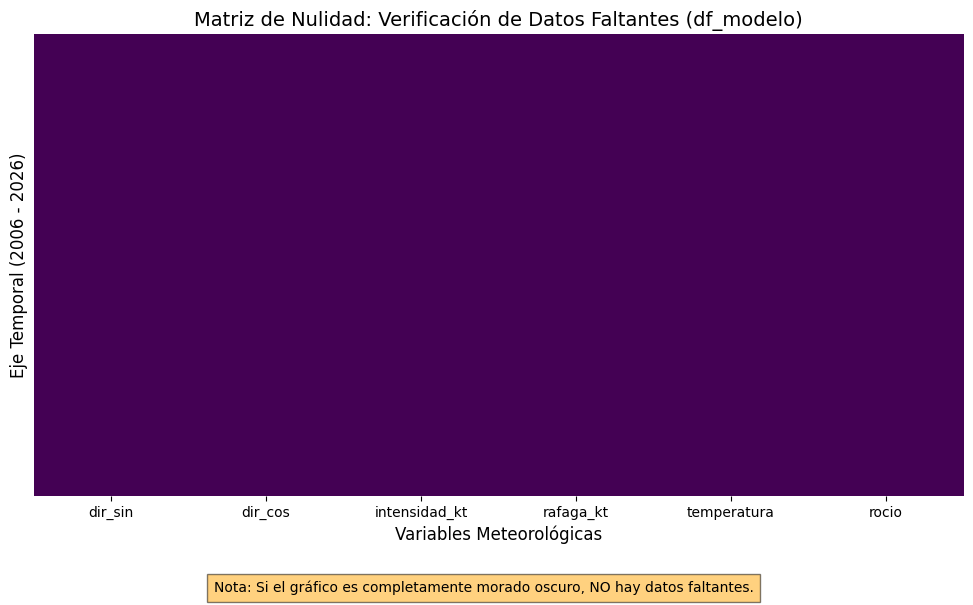

In [49]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear un heatmap directamente sobre los valores booleanos de df.isnull()
# cbar=False quita la barra lateral, yticklabels=False oculta las miles de fechas del eje Y
sns.heatmap(df_modelo.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Matriz de Nulidad: Verificación de Datos Faltantes (df_modelo)', fontsize=14)
plt.xlabel('Variables Meteorológicas', fontsize=12)
plt.ylabel('Eje Temporal (2006 - 2026)', fontsize=12)

# Añadir un texto explicativo dentro del gráfico
plt.figtext(0.5, -0.05, "Nota: Si el gráfico es completamente morado oscuro, NO hay datos faltantes.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.show()

In [50]:
# Filtrar desde 2013
df_lstm = df_modelo.loc['2013-01-01':, ['dir_sin', 'dir_cos', 'intensidad_kt', 'rafaga_kt', 'temperatura','rocio']].copy()

## Modelo CatBoost

In [51]:
import pandas as pd
import numpy as np

def crear_dataset_catboost_v2(df, n_lags=24):
    """
    Estructura datos para CatBoost prediciendo Intensidad (rafaga_kt) 
    y Dirección (dir_sin, dir_cos).
    """
    df_cb = df.copy()
    
    # 1. Crear Lags para las variables principales
    # Incluimos rafaga, sin, cos, temperatura y rocio para dar contexto completo
    cols_para_lags = ['dir_sin', 'dir_cos', 'intensidad_kt','rafaga_kt', 'temperatura', 'rocio']
    
    for col in cols_para_lags:
        for i in range(1, n_lags + 1):
            df_cb[f'{col}_lag_{i}'] = df_cb[col].shift(i)
        
    # 2. Estadísticas Móviles (Rolling)
    # La media de la intensidad y el seno/coseno en las últimas 6h ayuda a captar la tendencia
    df_cb['mean_kt_6h'] = df_cb['intensidad_kt'].rolling(window=6).mean()
    df_cb['mean_sin_6h'] = df_cb['dir_sin'].rolling(window=6).mean()
    df_cb['mean_cos_6h'] = df_cb['dir_cos'].rolling(window=6).mean()
    
    # 3. Extraer Variables Temporales
    df_cb['hour'] = df_cb.index.hour
    df_cb['month'] = df_cb.index.month
    
    # 4. Definir Targets para el horizonte de 6 horas
    # Ahora tenemos 3 targets por hora: intensidad, seno y coseno
    for h in range(1, 7):
        df_cb[f'target_kt_h{h}'] = df_cb['intensidad_kt'].shift(-h)
        df_cb[f'target_sin_h{h}'] = df_cb['dir_sin'].shift(-h)
        df_cb[f'target_cos_h{h}'] = df_cb['dir_cos'].shift(-h)
    
    # Eliminar filas con NaN (24 del inicio por lags, 6 del final por targets)
    df_cb.dropna(inplace=True)
    
    return df_cb

In [52]:
df_lstm = crear_dataset_catboost_v2(df_lstm)

/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9379/2139719808.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cb[f'{col}_lag_{i}'] = df_cb[col].shift(i)
/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9379/2139719808.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cb['mean_kt_6h'] = df_cb['intensidad_kt'].rolling(window=6).mean()
/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9379/2139719808.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result 

In [53]:
df_lstm.tail()

,dir_sin,dir_cos,intensidad_kt,rafaga_kt,temperatura,rocio,dir_sin_lag_1,dir_sin_lag_2,dir_sin_lag_3,dir_sin_lag_4,...,target_cos_h3,target_kt_h4,target_sin_h4,target_cos_h4,target_kt_h5,target_sin_h5,target_cos_h5,target_kt_h6,target_sin_h6,target_cos_h6
FECHA_REPORTE,,,,,,,,,,,,,,,,,,,,,
2026-04-09 08:00:00,0.500000,0.866025,3.0,0.0,11.0,11.0,0.766044,0.766044,0.939693,0.342020,...,0.642788,4.0,6.427876e-01,0.766044,3.0,9.396926e-01,0.342020,14.0,3.420201e-01,-0.939693
2026-04-09 09:00:00,0.500000,0.866025,3.0,0.0,11.0,11.0,0.500000,0.766044,0.766044,0.939693,...,0.766044,3.0,9.396926e-01,0.342020,14.0,3.420201e-01,-0.939693,17.0,5.000000e-01,-0.866025
2026-04-09 10:00:00,0.342020,0.939693,4.0,0.0,11.0,11.0,0.500000,0.500000,0.766044,0.766044,...,0.342020,14.0,3.420201e-01,-0.939693,17.0,5.000000e-01,-0.866025,15.0,1.224647e-16,-1.000000
2026-04-09 11:00:00,0.766044,0.642788,5.0,0.0,12.0,12.0,0.342020,0.500000,0.500000,0.766044,...,-0.939693,17.0,5.000000e-01,-0.866025,15.0,1.224647e-16,-1.000000,11.0,5.000000e-01,-0.866025
2026-04-09 12:00:00,0.642788,0.766044,4.0,0.0,13.0,12.0,0.766044,0.342020,0.500000,0.500000,...,-0.866025,15.0,1.224647e-16,-1.000000,11.0,5.000000e-01,-0.866025,11.0,1.736482e-01,-0.984808


In [54]:
df_lstm.columns

Index(['dir_sin', 'dir_cos', 'intensidad_kt', 'rafaga_kt', 'temperatura',
       'rocio', 'dir_sin_lag_1', 'dir_sin_lag_2', 'dir_sin_lag_3',
       'dir_sin_lag_4',
       ...
       'target_cos_h3', 'target_kt_h4', 'target_sin_h4', 'target_cos_h4',
       'target_kt_h5', 'target_sin_h5', 'target_cos_h5', 'target_kt_h6',
       'target_sin_h6', 'target_cos_h6'],
      dtype='str', length=173)

In [55]:
# 1. Identificar columnas
features = [col for col in df_lstm.columns if 'target' not in col]
# Targets para las 6 horas (u y v)
targets = []
for h in range(1, 7):
    targets.extend([f'target_kt_h{h}', f'target_sin_h{h}', f'target_cos_h{h}'])

# 2. Separar variables exógenas categóricas
cat_features = ['hour', 'month']

In [56]:
# Train: 2013 - 2024
train_df = df_lstm.loc[:'2024-12-31']
# Validation: 2025 (para early stopping)
val_df   = df_lstm.loc['2025-01-01':'2025-12-31']
# Test: 2026
test_df  = df_lstm.loc['2026-01-01':]

X_train, y_train = train_df[features], train_df[targets]
X_val, y_val     = val_df[features], val_df[targets]
X_test, y_test   = test_df[features], test_df[targets]

In [57]:
from catboost import CatBoostRegressor, Pool

# Crear objetos Pool para optimizar memoria
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val, y_val, cat_features=cat_features)

model_cb = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiRMSE',
    eval_metric='MultiRMSE',
    random_seed=42,
    has_time=True,          # Respeta el orden temporal interno
    verbose=100
)

In [58]:
model_cb.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
    use_best_model=True
)

0:	learn: 12.9166047	test: 7.4624283	best: 7.4624283 (0)	total: 2.46s	remaining: 1h 22m 5s
100:	learn: 9.7768389	test: 5.1860200	best: 5.1860200 (100)	total: 4m 34s	remaining: 1h 25m 56s
200:	learn: 8.7837942	test: 5.1293312	best: 5.1293312 (200)	total: 10m 1s	remaining: 1h 29m 42s
300:	learn: 8.1129656	test: 5.0987599	best: 5.0987599 (300)	total: 15m 51s	remaining: 1h 29m 29s
400:	learn: 7.5271646	test: 5.0843708	best: 5.0840834 (399)	total: 22m 5s	remaining: 1h 28m 6s
500:	learn: 7.0916867	test: 5.0698957	best: 5.0698957 (500)	total: 28m 18s	remaining: 1h 24m 42s
600:	learn: 6.7745849	test: 5.0618188	best: 5.0618188 (600)	total: 34m 18s	remaining: 1h 19m 52s
700:	learn: 6.5510844	test: 5.0529495	best: 5.0529319 (699)	total: 39m 46s	remaining: 1h 13m 41s
800:	learn: 6.3729951	test: 5.0480439	best: 5.0480439 (800)	total: 45m 4s	remaining: 1h 7m 28s
900:	learn: 6.2582370	test: 5.0421034	best: 5.0420880 (899)	total: 50m 11s	remaining: 1h 1m 13s
1000:	learn: 6.1516333	test: 5.0376296	best

CatBoostRegressor(depth=8, eval_metric='MultiRMSE', has_time=True, iterations=2000, learning_rate=0.05, loss_function='MultiRMSE', random_seed=42, verbose=100)

In [59]:
y_pred_cb = model_cb.predict(X_test)

# 2. Verificar la forma del resultado
# Debería ser (Número de filas en test, 12)
print(f"Forma de las predicciones: {y_pred_cb.shape}")

Forma de las predicciones: (2365, 18)


In [60]:
y_pred_cb

array([[ 5.81002641,  0.65881868,  0.37376952, ...,  4.04931499,
         0.55349095,  0.62948518],
       [ 5.13278152,  0.54373483,  0.57795443, ...,  3.86921842,
         0.47792381,  0.6464423 ],
       [ 5.13828274,  0.71504086,  0.58801039, ...,  4.02319432,
         0.55194458,  0.6526673 ],
       ...,
       [ 3.75016256,  0.5322778 ,  0.74774134, ...,  7.36190896,
         0.69164179, -0.16405421],
       [ 4.7823592 ,  0.72232408,  0.66206847, ...,  8.21496571,
         0.70081728, -0.35691242],
       [ 4.88260573,  0.68125756,  0.60170636, ...,  8.16012228,
         0.52074886, -0.3351353 ]], shape=(2365, 18))

In [61]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

def evaluar_rendimiento_hibrido(y_real, y_pred, horizon=6):
    """
    Evalúa el rendimiento para el modelo con targets: [Intensidad, Sin, Cos]
    y_real: DataFrame con 18 columnas (target_kt_h1, target_sin_h1, target_cos_h1...)
    y_pred: Array de NumPy (N, 18)
    """
    reporte_datos = []

    for h in range(1, horizon + 1):
        # 1. Definir índices para el bloque de la hora actual (bloques de 3)
        idx_int = (h - 1) * 3
        idx_sin = idx_int + 1
        idx_cos = idx_int + 2
        
        # 2. Extraer valores reales
        int_true = y_real.iloc[:, idx_int].values
        sin_true = y_real.iloc[:, idx_sin].values
        cos_true = y_real.iloc[:, idx_cos].values
        
        # 3. Extraer valores predichos
        int_pred = y_pred[:, idx_int]
        sin_pred = y_pred[:, idx_sin]
        cos_pred = y_pred[:, idx_cos]
        
        # 4. Cálculo de Dirección (Grados)
        # Reconstruimos el ángulo a partir de los componentes de fase
        dir_true = np.degrees(np.arctan2(sin_true, cos_true)) % 360
        dir_pred = np.degrees(np.arctan2(sin_pred, cos_pred)) % 360
        
        # 5. Cálculo de MAE Intensidad (kt)
        # Nota: La intensidad ya viene como target, no hay que calcular magnitud
        mae_int = mean_absolute_error(int_true, int_pred)
        
        # 6. Cálculo de MAE Dirección (Circular)
        diff_dir = np.abs(dir_true - dir_pred)
        mae_dir = np.mean(np.minimum(diff_dir, 360 - diff_dir))
        
        reporte_datos.append({
            'Hora': f'H+{h}',
            'MAE_Intensidad (kt)': round(mae_int, 3),
            'MAE_Direccion (deg)': round(mae_dir, 3)
        })

    # Crear DataFrame de reporte
    reporte_df = pd.DataFrame(reporte_datos).set_index('Hora')
    return reporte_df

In [62]:
# --- EJECUCIÓN ---
# Asegúrate de que y_test sea tu DataFrame de targets de 2026
# y_pred_cb es el resultado de model_cb.predict(X_test)
reporte_mae = evaluar_rendimiento_hibrido(y_test, y_pred_cb)

print("--- RESULTADOS DEL MODELO CATBOOST ---")
print(reporte_mae)

--- RESULTADOS DEL MODELO CATBOOST ---
      MAE_Intensidad (kt)  MAE_Direccion (deg)
Hora                                          
H+1                 1.244               31.196
H+2                 1.328               38.456
H+3                 1.407               40.826
H+4                 1.452               41.918
H+5                 1.482               42.900
H+6                 1.498               43.695


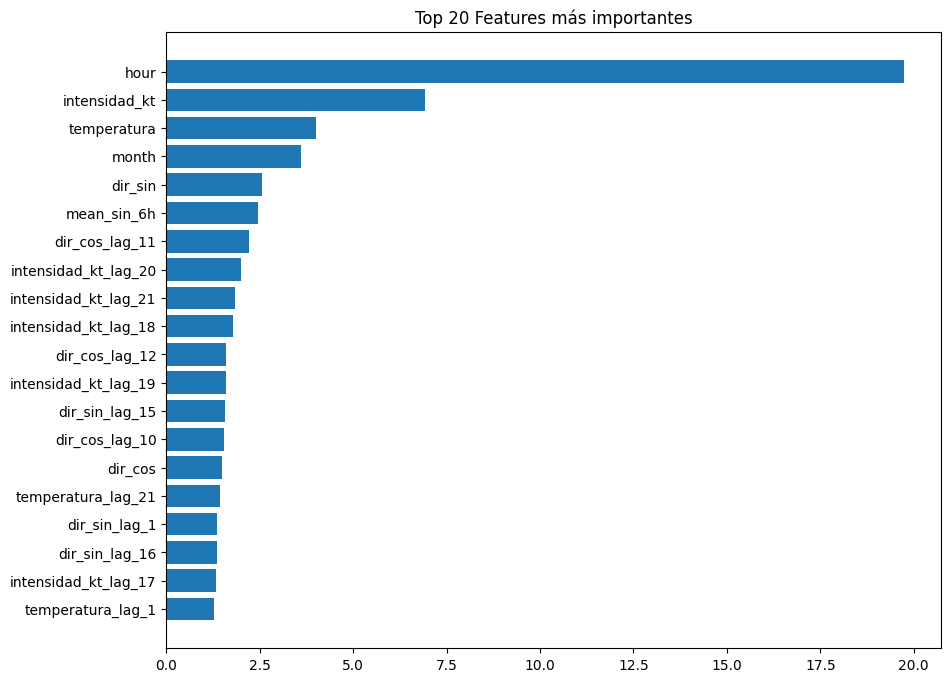

In [63]:
import matplotlib.pyplot as plt

feature_importance = model_cb.get_feature_importance(train_pool)
feature_names = X_train.columns
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Grafica las primeras 20
plt.figure(figsize=(10, 8))
plt.barh(feature_importances['feature'][:20], feature_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 Features más importantes")
plt.show()

In [64]:
def evaluar_rendimiento_hibrido_filtrado(y_real, y_pred, horizon=6, umbral_calma=3.0):
    """
    Evalúa el rendimiento diferenciando entre error total y error con viento significativo.
    """
    reporte_datos = []

    for h in range(1, horizon + 1):
        idx_int = (h - 1) * 3
        idx_sin = idx_int + 1
        idx_cos = idx_int + 2
        
        # 1. Extraer valores
        int_true = y_real.iloc[:, idx_int].values
        int_pred = y_pred[:, idx_int]
        sin_true, cos_true = y_real.iloc[:, idx_sin].values, y_real.iloc[:, idx_cos].values
        sin_pred, cos_pred = y_pred[:, idx_sin], y_pred[:, idx_cos]
        
        # 2. Conversión a Grados
        dir_true = np.degrees(np.arctan2(sin_true, cos_true)) % 360
        dir_pred = np.degrees(np.arctan2(sin_pred, cos_pred)) % 360
        
        # 3. Cálculo de Error Circular Individual
        diff_dir = np.abs(dir_true - dir_pred)
        error_dir_indiv = np.minimum(diff_dir, 360 - diff_dir)
        
        # 4. APLICAR FILTRO DE CALMA
        # Mascara booleana: ¿Donde el viento real es mayor al umbral?
        mask_viento = int_true > umbral_calma
        
        # MAE Dirección Total vs Filtrado
        mae_dir_total = np.mean(error_dir_indiv)
        # Solo promediamos donde la máscara es True
        mae_dir_filtrado = np.mean(error_dir_indiv[mask_viento]) if any(mask_viento) else np.nan
        
        # MAE Intensidad (kt) - Se evalúa sobre el total generalmente
        mae_int = mean_absolute_error(int_true, int_pred)
        
        reporte_datos.append({
            'Hora': f'H+{h}',
            'MAE_Int_Total': round(mae_int, 3),
            'MAE_Dir_Total': round(mae_dir_total, 3),
            'MAE_Dir_>3kt': round(mae_dir_filtrado, 3),
            'Casos_Viento_%': round(mask_viento.mean() * 100, 1) # Porcentaje de datos evaluados
        })

    reporte_df = pd.DataFrame(reporte_datos).set_index('Hora')
    return reporte_df

In [78]:
# --- EJECUCIÓN ---
reporte_final = evaluar_rendimiento_hibrido_filtrado(y_test, y_pred_cb, umbral_calma=3.0)
print(reporte_final)

      MAE_Int_Total  MAE_Dir_Total  MAE_Dir_>3kt  Casos_Viento_%
Hora                                                            
H+1           1.244         31.196        33.527            57.5
H+2           1.328         38.456        39.330            57.5
H+3           1.407         40.826        41.965            57.5
H+4           1.452         41.918        43.511            57.5
H+5           1.482         42.900        44.526            57.5
H+6           1.498         43.695        45.414            57.5


## Modelo 2

In [79]:
df_modelo.head()

,dir_sin,dir_cos,intensidad_kt,rafaga_kt,temperatura,rocio
FECHA_REPORTE,,,,,,
2006-07-20 00:00:00,0.500000,0.866025,4.0,0.0,13.0,8.00
2006-07-20 01:00:00,-0.939693,0.342020,4.0,0.0,11.0,10.00
2006-07-20 02:00:00,-0.939693,0.342020,3.5,0.0,10.5,9.75
2006-07-20 03:00:00,-0.939693,0.342020,3.0,0.0,10.0,9.50
2006-07-20 04:00:00,-0.939693,0.342020,2.5,0.0,9.5,9.25


In [80]:
def crear_dataset_catboost_v3(df, n_lags=24):
    """
    Versión optimizada: Incluye ingeniería de variables cíclicas, 
    tendencias térmicas y estabilidad atmosférica.
    """
    df_cb = df.copy()
    
    # 1. CODIFICACIÓN CÍCLICA DE LA HORA (Crucial por su alta importancia)
    # Esto ayuda al modelo a entender que las 23:00 y las 00:00 son contiguas
    df_cb['hour_sin'] = np.sin(2 * np.pi * df_cb.index.hour / 24)
    df_cb['hour_cos'] = np.cos(2 * np.pi * df_cb.index.hour / 24)
    
    # 2. INGENIERÍA DE VARIABLES FÍSICAS (Deltas y Spread)
    # Tendencia de temperatura (1h): ¿Se está calentando el aire?
    df_cb['delta_temp_1h'] = df_cb['temperatura'].diff(1)
    # Tendencia de temperatura (3h): Para captar cambios de masa de aire
    df_cb['delta_temp_3h'] = df_cb['temperatura'].diff(3)
    # Spread o Depresión del punto de rocío: Indicador de inestabilidad
    df_cb['spread'] = df_cb['temperatura'] - df_cb['rocio']
    
    # 3. ESTADÍSTICAS MÓVILES DE CORTO PLAZO (Inercia)
    # Forzamos al modelo a mirar qué ha pasado en las últimas 3 horas
    df_cb['rolling_sin_3h'] = df_cb['dir_sin'].rolling(window=3).mean()
    df_cb['rolling_cos_3h'] = df_cb['dir_cos'].rolling(window=3).mean()
    df_cb['rolling_kt_3h'] = df_cb['intensidad_kt'].rolling(window=3).mean()

    # 4. CREACIÓN DE LAGS (Retardos)
    # Añadimos los deltas y el spread a los lags para que el modelo vea la historia de la inestabilidad
    cols_para_lags = ['dir_sin', 'dir_cos', 'intensidad_kt','rafaga_kt', 'temperatura', 'delta_temp_1h', 'spread']
    
    for col in cols_para_lags:
        for i in range(1, n_lags + 1):
            df_cb[f'{col}_lag_{i}'] = df_cb[col].shift(i)
        
    # 5. VARIABLES CATEGÓRICAS (Mantenemos mes)
    df_cb['month'] = df_cb.index.month
    
    # 6. DEFINICIÓN DE TARGETS (Horizonte de 6 horas)
    for h in range(1, 7):
        df_cb[f'target_kt_h{h}'] = df_cb['rafaga_kt'].shift(-h)
        df_cb[f'target_sin_h{h}'] = df_cb['dir_sin'].shift(-h)
        df_cb[f'target_cos_h{h}'] = df_cb['dir_cos'].shift(-h)
    
    # Limpiar nulos creados por diff, rolling y shift
    df_cb.dropna(inplace=True)
    
    return df_cb

In [81]:
df_modelo2 = crear_dataset_catboost_v2(df_lstm)

In [82]:
df_modelo2.tail()

,dir_sin,dir_cos,intensidad_kt,rafaga_kt,temperatura,rocio,dir_sin_lag_1,dir_sin_lag_2,dir_sin_lag_3,dir_sin_lag_4,...,target_cos_h3,target_kt_h4,target_sin_h4,target_cos_h4,target_kt_h5,target_sin_h5,target_cos_h5,target_kt_h6,target_sin_h6,target_cos_h6
FECHA_REPORTE,,,,,,,,,,,,,,,,,,,,,
2026-04-09 02:00:00,0.984808,0.173648,4.0,0.0,16.0,12.0,0.500000,0.766044,0.642788,0.766044,...,0.342020,3.0,0.766044,0.642788,2.0,0.766044,0.642788,3.0,0.500000,0.866025
2026-04-09 03:00:00,0.939693,0.342020,4.0,0.0,12.0,11.0,0.984808,0.500000,0.766044,0.642788,...,0.642788,2.0,0.766044,0.642788,3.0,0.500000,0.866025,3.0,0.500000,0.866025
2026-04-09 04:00:00,0.342020,0.939693,3.0,0.0,12.0,11.0,0.939693,0.984808,0.500000,0.766044,...,0.642788,3.0,0.500000,0.866025,3.0,0.500000,0.866025,4.0,0.342020,0.939693
2026-04-09 05:00:00,0.939693,0.342020,4.0,0.0,11.0,11.0,0.342020,0.939693,0.984808,0.500000,...,0.866025,3.0,0.500000,0.866025,4.0,0.342020,0.939693,5.0,0.766044,0.642788
2026-04-09 06:00:00,0.766044,0.642788,3.0,0.0,11.0,11.0,0.939693,0.342020,0.939693,0.984808,...,0.866025,4.0,0.342020,0.939693,5.0,0.766044,0.642788,4.0,0.642788,0.766044


In [83]:
# 1. Identificar columnas
features = [col for col in df_lstm.columns if 'target' not in col]
# Targets para las 6 horas (u y v)
targets = []
for h in range(1, 7):
    targets.extend([f'target_kt_h{h}', f'target_sin_h{h}', f'target_cos_h{h}'])

# 2. Separar variables exógenas categóricas
cat_features = ['hour', 'month']

# Train: 2013 - 2024
train_df = df_lstm.loc[:'2024-12-31']
# Validation: 2025 (para early stopping)
val_df   = df_lstm.loc['2025-01-01':'2025-12-31']
# Test: 2026
test_df  = df_lstm.loc['2026-01-01':]

X_train, y_train = train_df[features], train_df[targets]
X_val, y_val     = val_df[features], val_df[targets]
X_test, y_test   = test_df[features], test_df[targets]

In [84]:
# Crear objetos Pool para optimizar memoria
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val, y_val, cat_features=cat_features)

model_cb2 = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiRMSE',
    eval_metric='MultiRMSE',
    random_seed=42,
    has_time=True,          # Respeta el orden temporal interno
    verbose=100
)

In [86]:
model_cb2.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
    use_best_model=True
)

0:	learn: 12.9166047	test: 7.4624283	best: 7.4624283 (0)	total: 2.62s	remaining: 1h 27m 21s
100:	learn: 9.7768389	test: 5.1860200	best: 5.1860200 (100)	total: 5m 38s	remaining: 1h 46m 5s
200:	learn: 8.7837942	test: 5.1293312	best: 5.1293312 (200)	total: 11m 51s	remaining: 1h 46m 11s
300:	learn: 8.1129656	test: 5.0987599	best: 5.0987599 (300)	total: 18m 53s	remaining: 1h 46m 37s
400:	learn: 7.5271646	test: 5.0843708	best: 5.0840834 (399)	total: 26m 17s	remaining: 1h 44m 50s
500:	learn: 7.0916867	test: 5.0698957	best: 5.0698957 (500)	total: 31m 30s	remaining: 1h 34m 15s
600:	learn: 6.7745849	test: 5.0618188	best: 5.0618188 (600)	total: 36m 16s	remaining: 1h 24m 25s
700:	learn: 6.5510844	test: 5.0529495	best: 5.0529319 (699)	total: 41m 44s	remaining: 1h 17m 21s
800:	learn: 6.3729951	test: 5.0480439	best: 5.0480439 (800)	total: 48m 29s	remaining: 1h 12m 34s
900:	learn: 6.2582370	test: 5.0421034	best: 5.0420880 (899)	total: 54m 47s	remaining: 1h 6m 49s
1000:	learn: 6.1516333	test: 5.0376296

CatBoostRegressor(depth=8, eval_metric='MultiRMSE', has_time=True, iterations=2000, learning_rate=0.05, loss_function='MultiRMSE', random_seed=42, verbose=100)